# Step 01 — SQLite post-fit pipeline and hidden-mechanism simulation

This notebook validates the implemented **step 01** pipeline against the historical SQLite studies.

Scope of this step:

- read best/top-N trials directly from SQLite without Optuna;
- export normalized effective parameters;
- demonstrate exact `d × pk` structural confounding through `P_gap_eff`;
- simulate representative best trials with hidden-current outputs.

This step remains **provisional**. The historical DBs are single-current fits and do not replace the later six-sweep cell-specific inference.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path(os.environ.get('ASTROMODEL_PROJECT_ROOT', Path.cwd())).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.optuna_sqlite import read_best_trial
from src.postfit_sqlite import (
    DEFAULT_REPRESENTATIVE_DBS,
    d_pk_invariance_check,
    run_step01_postfit_sqlite,
)

print(f'PROJECT_ROOT={PROJECT_ROOT}')

PROJECT_ROOT=/mnt/data/astromodel_impl


In [2]:
results = run_step01_postfit_sqlite(PROJECT_ROOT, top_n=5)
top_trials = results['top_trials_all_dbs']
effective_summary = results['effective_parameter_summary']
representative_summary = results['representative_mechanism_summary']
representative_simulations = results['representative_simulations']

print('written outputs:', sorted((PROJECT_ROOT / 'outputs' / 'postfit_sqlite').glob('*.csv')))
print('top-trial rows:', len(top_trials))

written outputs: [PosixPath('/mnt/data/astromodel_impl/outputs/postfit_sqlite/effective_parameter_summary.csv'), PosixPath('/mnt/data/astromodel_impl/outputs/postfit_sqlite/representative_mechanism_summary.csv'), PosixPath('/mnt/data/astromodel_impl/outputs/postfit_sqlite/top_trials_all_dbs.csv')]
top-trial rows: 90


## Direct SQLite post-fit tables

In [3]:
display(top_trials.head(15))
display(effective_summary)

summary_by_condition = effective_summary.groupby('condition')[['P_gap_eff', 'gamma_t_eff', 'gamma_s_eff', 'volume_ratio_wa_wo']].median()
display(summary_by_condition)

,db_name,study_name,condition,current_na,trial_id,trial_number,objective,K_bath_value_middle,Va_l,Va_s,ca,d,eps,eps_middle,gki,gl_a,gs,gt,pk,switching_function,wo,zs,zth,wo_middle,w_a,P_gap_eff,gamma_t_eff,gamma_s_eff,volume_ratio_wa_wo
0,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,1,0,3450.286230,5.795238,-50.964922,-91.0,315.0,0.909128,0.039213,0.412861,131.189632,13.023393,5.665444,9.261681,0.000420,tanh,720.348665,11.982228,102.558776,1.0,2000.0,0.000382,0.000077,0.000047,2.776433
1,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,9250,9249,3704.158782,5.762007,-57.497915,-91.0,330.0,0.351544,0.060564,0.429561,92.376106,3.173833,21.023631,31.174990,0.000487,tanh,431.886769,16.033473,88.678969,1.0,2000.0,0.000171,0.000258,0.000174,4.630843
2,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,10757,10756,3817.833494,5.790071,-48.640404,-92.0,307.0,1.351600,0.057778,0.329690,174.001761,10.733566,14.502028,4.718830,0.000591,tanh,546.233043,11.492763,92.118543,1.0,2000.0,0.000798,0.000039,0.000120,3.661441
3,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,6582,6581,4049.167273,5.716857,-63.372429,-99.0,350.0,0.749554,0.025823,0.415357,132.256912,0.037012,7.591852,10.152396,0.001466,tanh,1563.605422,11.729167,85.069005,1.0,2000.0,0.001099,0.000084,0.000063,1.279095
4,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,1363,1362,4251.275192,5.807791,-58.856466,-96.0,348.0,1.163089,0.018271,0.416921,97.649845,24.719565,10.834828,42.767483,0.000301,tanh,1896.699602,7.461471,48.455424,1.0,2000.0,0.000350,0.000355,0.000090,1.054463
5,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,1,0,5848.293742,6.524304,-41.137523,-96.0,304.0,0.123067,0.034144,0.378066,194.550497,15.059161,38.446247,3.961756,0.004181,tanh,879.410688,12.509314,56.473963,1.0,2000.0,0.000515,0.000033,0.000319,2.274250
6,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,6217,6216,6205.336302,6.689067,-66.638155,-91.0,316.0,0.679546,0.022638,0.332124,65.199497,25.790313,20.359504,7.003679,0.000421,tanh,1654.869387,15.145474,96.473521,1.0,2000.0,0.000286,0.000058,0.000169,1.208555
7,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,3019,3018,6437.226659,6.526947,-68.222558,-95.0,357.0,0.164008,0.097777,0.267446,116.718020,29.494174,47.076311,3.131707,0.004400,tanh,602.753908,18.093044,83.307014,1.0,2000.0,0.000722,0.000026,0.000390,3.318104
8,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,9089,9088,6575.427731,6.460255,-56.314821,-93.0,398.0,0.305112,0.039873,0.234291,191.404771,25.497542,44.261471,1.505312,0.005144,tanh,1941.331401,4.547688,93.714185,1.0,2000.0,0.001570,0.000012,0.000367,1.030221
9,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,7270,7269,6760.275338,6.707583,-61.385306,-91.0,385.0,0.273180,0.017783,0.357415,80.262077,27.297286,32.606052,3.497787,0.001322,tanh,1575.922143,9.129203,102.827303,1.0,2000.0,0.000361,0.000029,0.000270,1.269098


,db_name,study_name,condition,current_na,trial_id,trial_number,objective,P_gap_eff,gamma_t_eff,gamma_s_eff,volume_ratio_wa_wo
0,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,1,0,3450.286230,3.820129e-04,0.000077,0.000047,2.776433
1,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,1,0,5848.293742,5.145793e-04,0.000033,0.000319,2.274250
2,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,1,0,7963.653221,3.060630e-04,0.000057,0.000329,2.888380
3,BARIUM_125nA.db,BARIUM_125nA_centered_L2_20000t_20240930_133313,BARIUM,125,1,0,13492.704819,2.694143e-04,0.000048,0.000112,1.585457
4,BARIUM_150nA.db,BARIUM_150nA_centered_L2_20000t_20240930_133313,BARIUM,150,4312,4311,23509.572968,2.099761e-04,0.000058,0.000255,3.071149
5,BARIUM_175nA.db,BARIUM_175nA_centered_L2_20000t_20240930_133313,BARIUM,175,1,0,28903.238239,3.980285e-04,0.000030,0.000016,1.585018
6,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,50,2068,2067,21.502226,4.282360e-06,0.000052,0.000091,1.308028
7,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,2426,2425,30.054498,7.688695e-06,0.000008,0.000069,1.527016
8,CONTROL_100nA.db,CONTROL_100nA_centered_L2_2500t,CONTROL,100,1944,1943,38.365141,4.567634e-08,0.000026,0.000080,1.465699
9,CONTROL_125nA.db,CONTROL_125nA_centered_L2_2500t,CONTROL,125,1930,1929,102.645495,6.177250e-08,0.000008,0.000131,1.014964


,P_gap_eff,gamma_t_eff,gamma_s_eff,volume_ratio_wa_wo
condition,,,,
BARIUM,3.440380e-04,0.000053,0.000184,2.525342
CONTROL,4.911552e-07,0.000032,0.000109,1.386864
MFA,6.457560e-05,0.000018,0.001280,0.190203


## Exact `d/pk` invariance demonstration

In [4]:
base_record = read_best_trial(PROJECT_ROOT / 'data' / '1_Initial_xp_fit' / 'CONTROL_75nA.db')
check = d_pk_invariance_check(base_record.params, experiment_type=base_record.condition, current_na=base_record.current_na, scale_factor=3.0)

demo = pd.DataFrame([
    {
        'P_gap_eff_a': check.P_gap_eff_a,
        'P_gap_eff_b': check.P_gap_eff_b,
        'I_kgap_a': check.I_kgap_a,
        'I_kgap_b': check.I_kgap_b,
        'max_abs_dzdt_diff': float(abs(check.dzdt_a - check.dzdt_b).max()),
    }
])
display(demo)

,P_gap_eff_a,P_gap_eff_b,I_kgap_a,I_kgap_b,max_abs_dzdt_diff
0,0.000008,0.000008,51.701181,51.701181,0.0


## Representative Vm traces

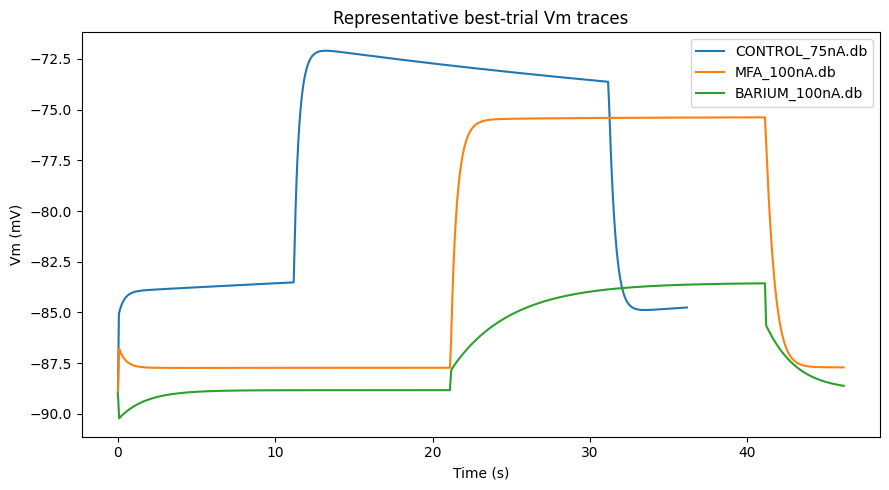

In [5]:
plt.figure(figsize=(9, 5))
for db_name, sim in representative_simulations.items():
    plt.plot(sim['t_ms'] / 1000.0, sim['Vm'], label=db_name)
plt.xlabel('Time (s)')
plt.ylabel('Vm (mV)')
plt.title('Representative best-trial Vm traces')
plt.legend()
plt.tight_layout()
plt.show()

## Representative hidden-current overlays

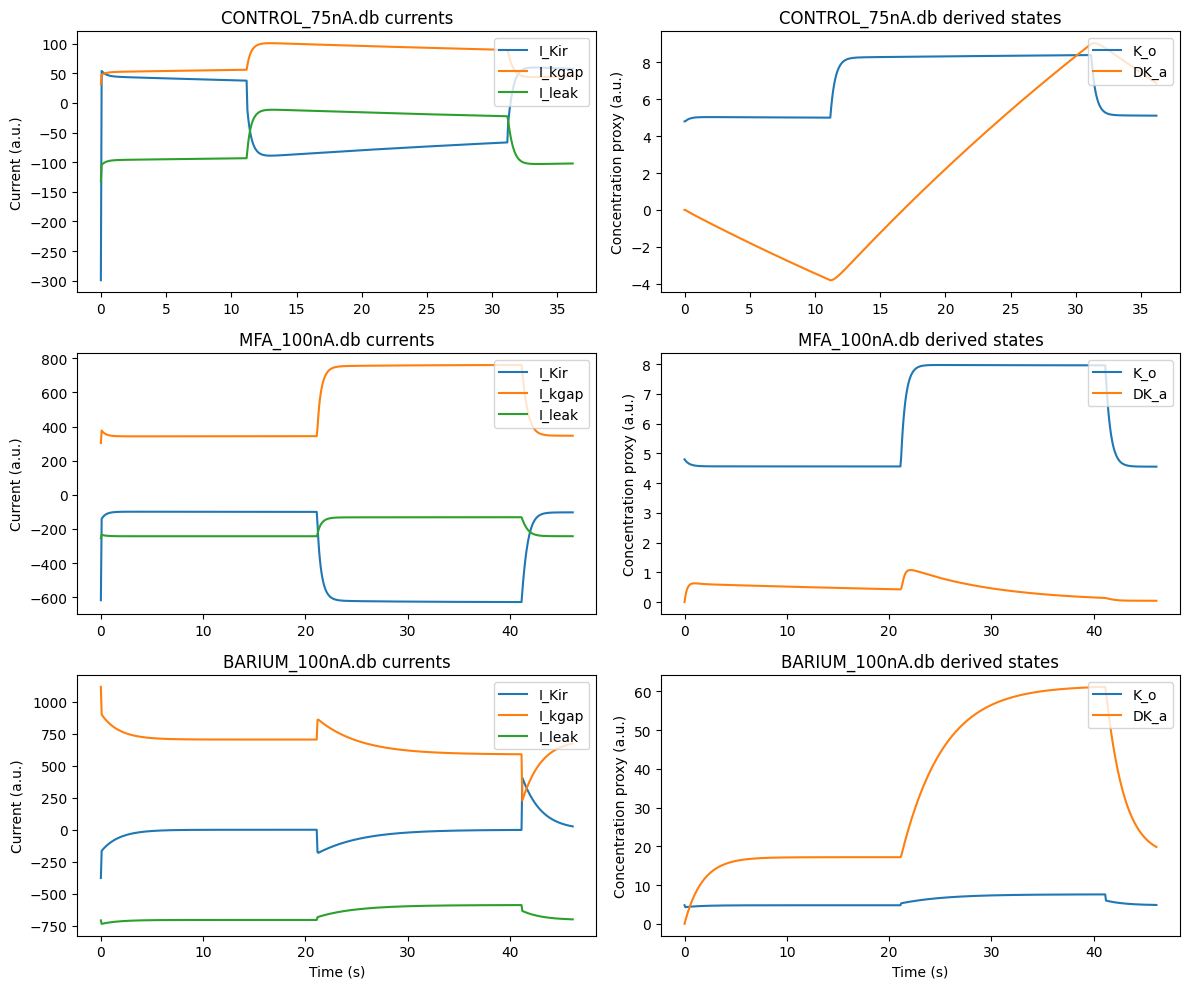

In [6]:
fig, axes = plt.subplots(len(DEFAULT_REPRESENTATIVE_DBS), 2, figsize=(12, 10), sharex=False)
for row_idx, db_name in enumerate(DEFAULT_REPRESENTATIVE_DBS):
    sim = representative_simulations[db_name]
    t_s = sim['t_ms'] / 1000.0
    axes[row_idx, 0].plot(t_s, sim['currents']['I_Kir'], label='I_Kir')
    axes[row_idx, 0].plot(t_s, sim['currents']['I_kgap'], label='I_kgap')
    axes[row_idx, 0].plot(t_s, sim['currents']['I_leak'], label='I_leak')
    axes[row_idx, 0].set_title(f'{db_name} currents')
    axes[row_idx, 0].set_ylabel('Current (a.u.)')
    axes[row_idx, 0].legend(loc='upper right')

    axes[row_idx, 1].plot(t_s, sim['derived']['K_o'], label='K_o')
    axes[row_idx, 1].plot(t_s, sim['derived']['DK_a'], label='DK_a')
    axes[row_idx, 1].set_title(f'{db_name} derived states')
    axes[row_idx, 1].set_ylabel('Concentration proxy (a.u.)')
    axes[row_idx, 1].legend(loc='upper right')

for ax in axes[-1, :]:
    ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## Representative mechanism and proxy summary

In [7]:
display(representative_summary)

,db_name,study_name,condition,current_na,trial_id,trial_number,objective,P_gap_eff,gamma_t_eff,gamma_s_eff,volume_ratio_wa_wo,I_Kir_integral,I_kgap_integral,I_leak_integral,I_k_a_integral,I_Kir_peak_abs,I_kgap_peak_abs,gap_to_kir_integral_ratio,gap_kir_classification,gap_fraction,kir_fraction,leak_fraction,K_o_baseline,K_o_peak,K_o_final,K_o_delta_peak,K_o_recovery_error,dominant_mechanism,proxy_proxy,proxy_target,proxy_pearson_r,proxy_spearman_r,proxy_rmse_after_scaling,proxy_lag_s_at_max_corr,proxy_validity_class
0,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,1,0,7963.653221,0.000306,0.000057,0.000329,2.888380,765.766317,12897.041463,12132.667975,0.0,180.187123,860.144335,16.842007,gap_dominant,0.499973,0.029686,0.470341,4.8,7.596770,4.877359,2.796770,0.077359,Mixed,DK_a_t,K_o,0.999925,1.00000,0.007149,0.0,strong
1,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,2426,2425,30.054498,0.000008,0.000008,0.000069,1.527016,1542.868912,1892.971968,358.014013,0.0,89.057630,100.638353,1.226917,mixed,0.498957,0.406676,0.094367,4.8,8.395908,5.109484,3.595908,0.309484,Mixed,DK_a_t,K_o,0.454297,1.00000,0.265254,0.0,weak
2,MFA_100nA.db,MFA_100nA_centered_COMBINED_20000t_2024-10-13_...,MFA,100,1,0,135164.788205,0.000065,0.000018,0.001280,0.190203,12337.933214,15019.795557,2686.617004,0.0,628.860053,760.533826,1.217367,mixed,0.499921,0.410657,0.089422,4.8,7.971894,4.553637,3.171894,0.246363,Mixed,DK_a_t,K_o,0.339423,-0.32304,0.322408,0.0,failed


## Interpretation

The historical SQLite studies are now readable without Optuna, structural `d/pk` confounding is demonstrated explicitly, and representative best trials expose hidden-current and proxy summaries. These outputs are useful for debugging and reviewer-facing diagnostics, but they remain provisional because they come from historical single-current fits rather than the final cell-specific six-sweep pipeline.